In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p "/content/drive/My Drive/AAI_FA2"

Mounted at /content/drive


In [ ]:
# Install required libraries
!pip install kagglehub librosa numpy matplotlib seaborn tensorflow
import kagglehub
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Download dataset
DATASET_PATH = kagglehub.dataset_download("daisukelab/dc2020task2")
print("Dataset downloaded to:", DATASET_PATH)

# Parameters
SAMPLE_RATE = 16000
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 2048
MAX_FRAMES = 512  # width

Dataset downloaded to: /kaggle/input/dc2020task2


In [ ]:
# Function to process audio file
def process_audio(file_path):
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=5.0)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, hop_length=HOP_LENGTH, n_fft=N_FFT)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    # Pad or truncate
    if mel_spec_db.shape[1] < MAX_FRAMES:
        pad_width = MAX_FRAMES - mel_spec_db.shape[1]
        mel_spec_db = np.pad(mel_spec_db, ((0, 0), (0, pad_width)), mode='constant')
    else:
        mel_spec_db = mel_spec_db[:, :MAX_FRAMES]

    # Normalize
    mel_spec_db = (mel_spec_db - np.min(mel_spec_db)) / (np.max(mel_spec_db) - np.min(mel_spec_db))
    return mel_spec_db

<ipython-input-4-f7e8e2313669>:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=5.0)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


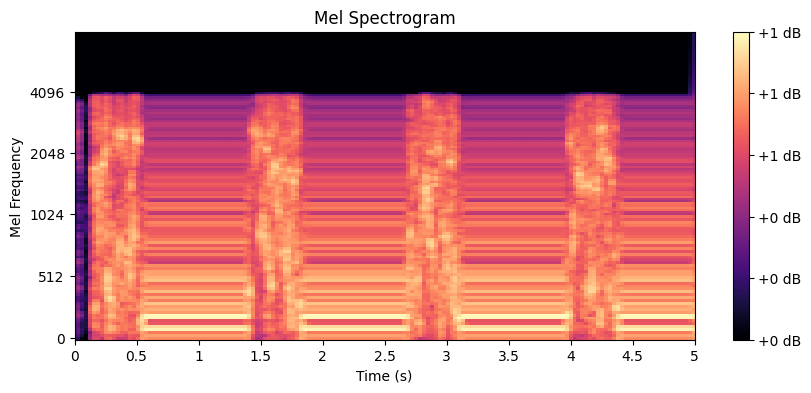

In [ ]:
import librosa.display
import matplotlib.pyplot as plt

# Function to display mel spectrogram
def plot_mel_spectrogram(mel_spec_db, sr=SAMPLE_RATE, hop_length=HOP_LENGTH):
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mel_spec_db, sr=sr, hop_length=hop_length, x_axis="time", y_axis="mel", cmap="magma")
    plt.colorbar(format="%+2.0f dB")
    plt.title("Mel Spectrogram")
    plt.xlabel("Time (s)")
    plt.ylabel("Mel Frequency")
    plt.xlim(0,5)
    plt.show()

# Load a sample audio file and process it
sample_file = "/content/drive/My Drive/AAI_FA2/mel_spectrograms.npy"
mel_spec_db = process_audio(sample_file)

# Plot the spectrogram
plot_mel_spectrogram(mel_spec_db)

In [ ]:
# Load normal spectrograms
spectrograms = []
count = 0
LIMIT = 4000
for root, _, files in os.walk(DATASET_PATH):
    for file in files:
        if file.startswith("normal") and file.endswith(".wav"):
            spectrograms.append(process_audio(os.path.join(root, file)))
            count += 1
            if count >= LIMIT:
                break
    if count >= LIMIT:
        break

spectrograms = np.array(spectrograms)
np.save("/content/drive/My Drive/AAI_FA2/mel_spectrograms.npy", spectrograms)

# Load anomaly spectrograms
test_spectro = []
count = 0
LIMIT = 600
for root, _, files in os.walk(DATASET_PATH):
    for file in files:
        if file.startswith("anomaly") and file.endswith(".wav"):
            test_spectro.append(process_audio(os.path.join(root, file)))
            count += 1
            if count >= LIMIT:
                break
    if count >= LIMIT:
        break

test_spectro = np.array(test_spectro)
np.save("/content/drive/My Drive/AAI_FA2/mel_spectrograms_test.npy", test_spectro)

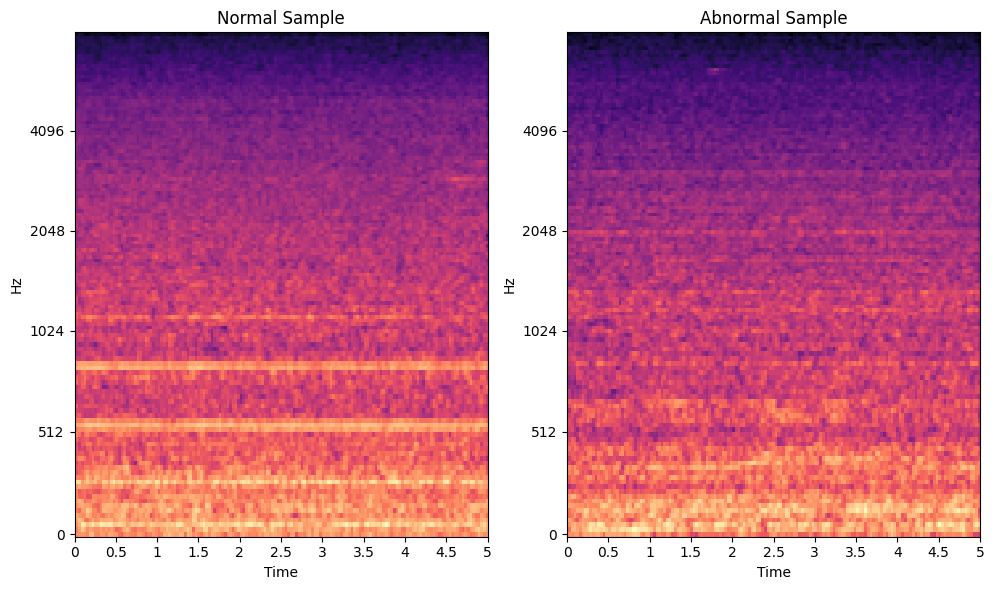

In [ ]:
import librosa.display

def plotLogMelSpect(normalSample, abnormalSample):
    fig, axes = plt.subplots(1, 2, figsize=(10, 6))
    normalSample = np.squeeze(normalSample)
    abnormalSample = np.squeeze(abnormalSample)

    vmin, vmax = normalSample.min(), normalSample.max()

    librosa.display.specshow(normalSample, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel", cmap="magma", ax=axes[0], vmin=vmin, vmax=vmax)
    axes[0].set_title("Normal Sample")

    librosa.display.specshow(abnormalSample, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel", cmap="magma", ax=axes[1], vmin=vmin, vmax=vmax)
    axes[1].set_title("Abnormal Sample")

    plt.tight_layout()
    axes[0].set_xlim(0, 5)
    axes[1].set_xlim(0, 5)
    plt.show()

plotLogMelSpect(spectrograms[0], test_spectro[0])

In [ ]:
import tensorflow as tf
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, BatchNormalization, Activation
from keras.callbacks import EarlyStopping

# spectrograms = np.expand_dims(spectrograms, axis=-1)

input_layer = Input(shape=(128, 512, 1))
x = Conv2D(32, (5,5), padding='same')(input_layer)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(16, (5,5), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(8, (5,5), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(8, (5,5), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = UpSampling2D((2,2))(x)

x = Conv2D(16, (5,5), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (5,5), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = UpSampling2D((2,2))(x)

output_layer = Conv2D(1, (5,5), activation='sigmoid', padding='same')(x)
autoencoder = Model(input_layer, output_layer)

autoencoder.compile(optimizer='adam', loss='msle')

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 221ms/step - loss: 0.0084 - val_loss: 0.0352
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 104ms/step - loss: 8.0992e-04 - val_loss: 0.0227
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - loss: 6.8188e-04 - val_loss: 0.0118
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - loss: 6.5722e-04 - val_loss: 0.0076
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - loss: 6.3585e-04 - val_loss: 0.0036
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - loss: 6.4183e-04 - val_loss: 0.0012
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - loss: 6.1926e-04 - val_loss: 6.9743e-04
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - loss: 6.1433e-04 - val_loss: 6.2773e-04
Epoch 9/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - loss: 5.9973e-04 - val_loss: 5.8792e-04
Epoch 10/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - loss: 5.7764e-04 - val_loss: 5.7653e-04
Epoch 11/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - loss: 5.8270e-04 - val_lo

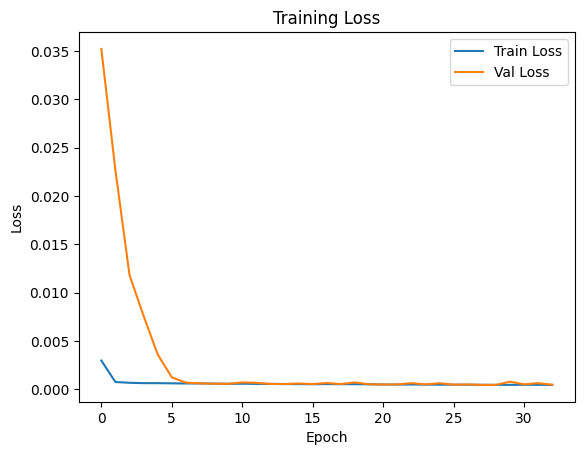

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, verbose=1, mode='min')
history = autoencoder.fit(
    spectrograms, spectrograms,
    epochs=50,
    batch_size=32,
    validation_split=0.3,
    callbacks=[early_stop]
)

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
autoencoder.save("/content/drive/My Drive/AAI_FA2/autoencoder_model.h5")
autoencoder.save("/content/drive/My Drive/AAI_FA2/autoencoder_model.keras")

In [ ]:
spectrograms = np.expand_dims(spectrograms, axis=-1)


test_data = np.load("/content/drive/My Drive/AAI_FA2/mel_spectrograms_test.npy")
test_data = np.expand_dims(test_data, axis=-1)

In [ ]:
from sklearn.utils import shuffle
import seaborn as sns

test_samples = np.concatenate((test_data[:10], spectrograms[:50]), axis=0)
testing = []
for i in range(60):
  if i<10:
    testing.append((test_samples[i],1))
  else:
    testing.append((test_samples[i],0))
#samples = shuffle(testing, random_state=42)

In [ ]:
y_demo = [i[1] for i in testing]
print(y_demo)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 4s/step


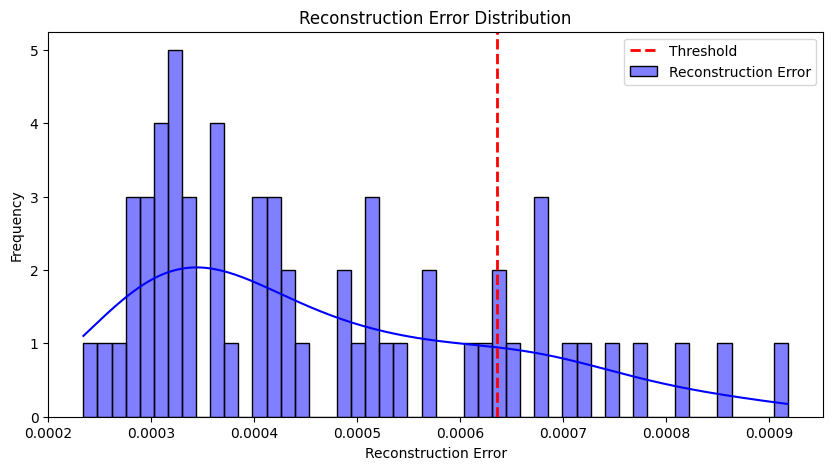

Detected 12 anomalies out of 60
Anomaly Threshold: 0.0006


In [ ]:
from sklearn.utils import shuffle
import seaborn as sns
samplings = np.array([i[0] for i in testing])
samples = shuffle(samplings, random_state=42)

y_true = [i[1] for i in testing]
# Predict
reconstructed = autoencoder.predict(samples)

# Log-scale MSE
reconstruction_errors = np.mean(np.square(np.log1p(samples) - np.log1p(reconstructed)), axis=(1,2,3))
threshold = np.mean(reconstruction_errors) + np.std(reconstruction_errors)
anomalies = reconstruction_errors > threshold

# Plot
plt.figure(figsize=(10, 5))
sns.histplot(reconstruction_errors, bins=50, kde=True, color='blue', label='Reconstruction Error')
plt.axvline(threshold, color='red', linestyle='dashed', linewidth=2, label='Threshold')
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.show()

# Results
print(f"Detected {np.sum(anomalies)} anomalies out of {len(samples)}")
print(f"Anomaly Threshold: {threshold:.4f}")

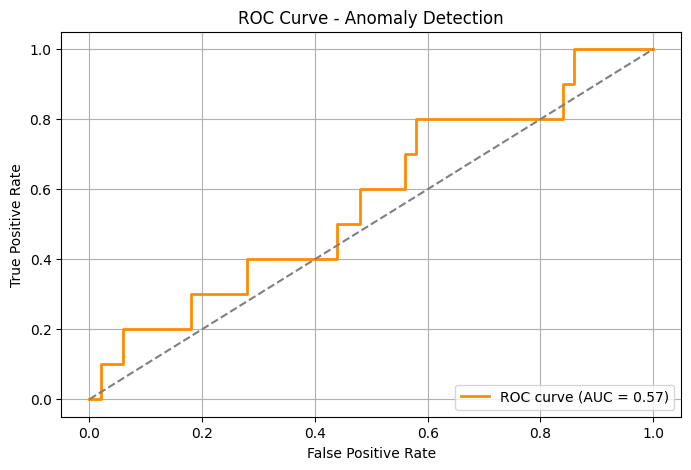

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, reconstruction_errors)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Anomaly Detection')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

<Figure size 600x500 with 0 Axes>

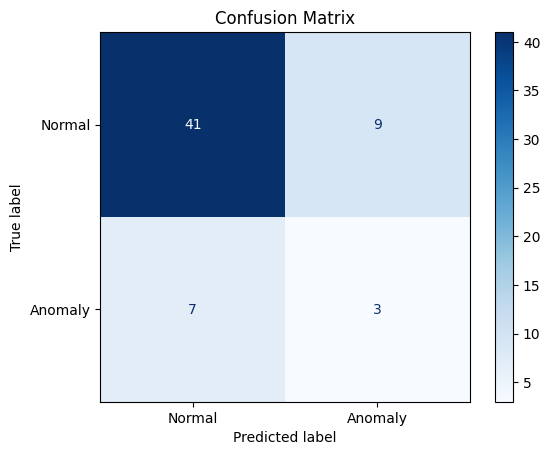

In [ ]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = (reconstruction_errors > threshold).astype(int)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])

plt.figure(figsize=(6, 5))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.show()

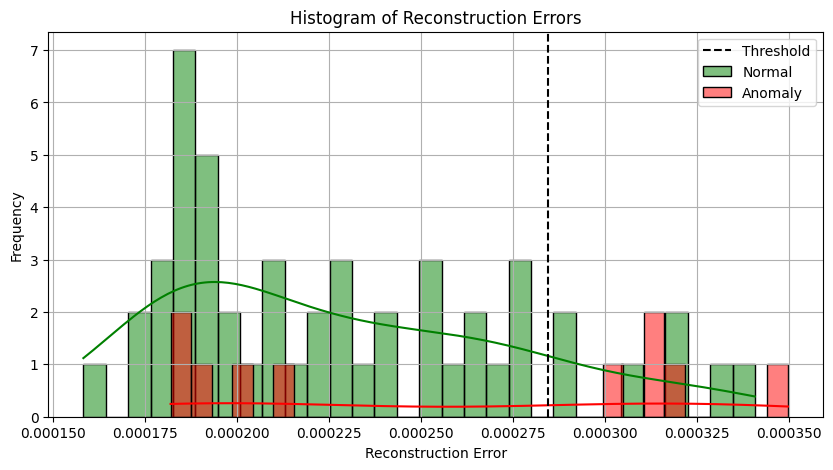

In [ ]:

normal_errors = reconstruction_errors[y_true == 0]
abnormal_errors = reconstruction_errors[y_true == 1]

plt.figure(figsize=(10, 5))
sns.histplot(normal_errors, color='green', label='Normal', kde=True, bins=30)
sns.histplot(abnormal_errors, color='red', label='Anomaly', kde=True, bins=30)
plt.axvline(threshold, color='black', linestyle='--', label='Threshold')
plt.title("Histogram of Reconstruction Errors")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()